In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [129]:
df=pd.read_csv("titanic.csv")
df = df.drop(columns=[
    'Name',
    'Ticket',
    'Cabin',
    'PassengerId'
])

In [130]:
df.shape

(891, 8)

C:\Users\shrey\AppData\Local\Temp\ipykernel_34504\2287907111.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


Text(0.5, 1.0, 'Boxplot of Age')

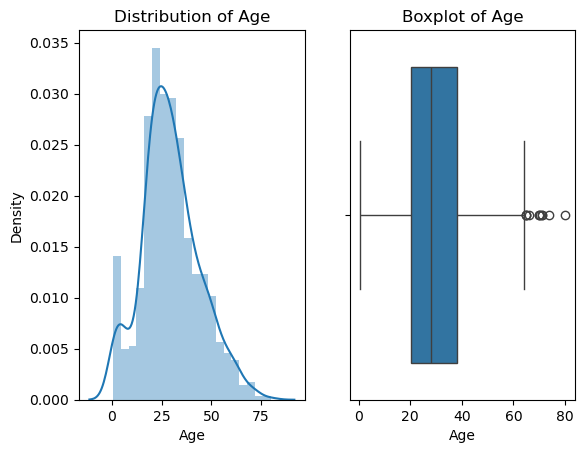

In [131]:
# Distplot
plt.subplot(1, 2, 1)
sns.distplot(df['Age'])
plt.title("Distribution of Age")

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")

In [132]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [133]:
pa25=df['Age'].quantile(0.25)
pa75=df['Age'].quantile(0.75)
iqr=pa75-pa25
ul=pa75+1.5*iqr
ll=pa25-1.5*iqr

In [134]:
ll

np.float64(-6.6875)

In [135]:
ul

np.float64(64.8125)

In [136]:
outliers=df[(df['Age']>ul) | (df['Age']<ll)]

In [137]:
outliers

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
33,0,2,male,66.0,0,0,10.5000,S
54,0,1,male,65.0,0,1,61.9792,C
96,0,1,male,71.0,0,0,34.6542,C
116,0,3,male,70.5,0,0,7.7500,Q
280,0,3,male,65.0,0,0,7.7500,Q
456,0,1,male,65.0,0,0,26.5500,S
493,0,1,male,71.0,0,0,49.5042,C
630,1,1,male,80.0,0,0,30.0000,S
672,0,2,male,70.0,0,0,10.5000,S
745,0,1,male,70.0,1,1,71.0000,S


In [138]:
df['Age'] = np.where(df['Age'] > ul,ul, np.where(df['Age'] < ll,ll,df['Age']) )

In [139]:
df.shape

(891, 8)

In [140]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [141]:
df=df.drop(columns=['SibSp','Parch'])

In [142]:
df.isnull().sum

<bound method DataFrame.sum of      Survived  Pclass    Sex    Age   Fare  Embarked  FamilySize
0       False   False  False  False  False     False       False
1       False   False  False  False  False     False       False
2       False   False  False  False  False     False       False
3       False   False  False  False  False     False       False
4       False   False  False  False  False     False       False
..        ...     ...    ...    ...    ...       ...         ...
886     False   False  False  False  False     False       False
887     False   False  False  False  False     False       False
888     False   False  False   True  False     False       False
889     False   False  False  False  False     False       False
890     False   False  False  False  False     False       False

[891 rows x 7 columns]>

In [143]:
df.shape

(891, 7)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         714 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked    889 non-null    object 
 6   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [145]:
df.isnull().sum()

Survived        0
Pclass          0
Sex             0
Age           177
Fare            0
Embarked        2
FamilySize      0
dtype: int64

In [146]:
df.duplicated().sum()

np.int64(114)

<Axes: xlabel='Age', ylabel='count'>

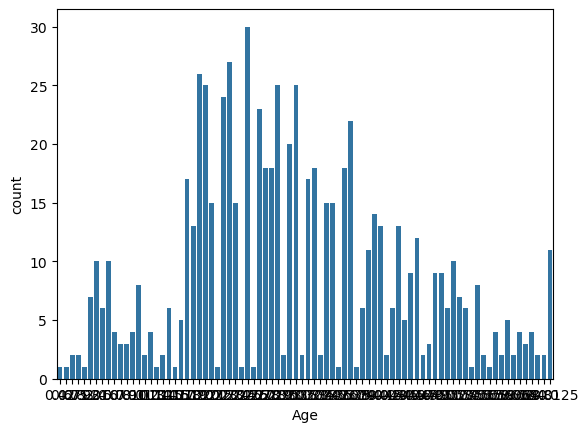

In [147]:
sns.countplot(x=df['Age'])


<Axes: xlabel='Sex', ylabel='count'>

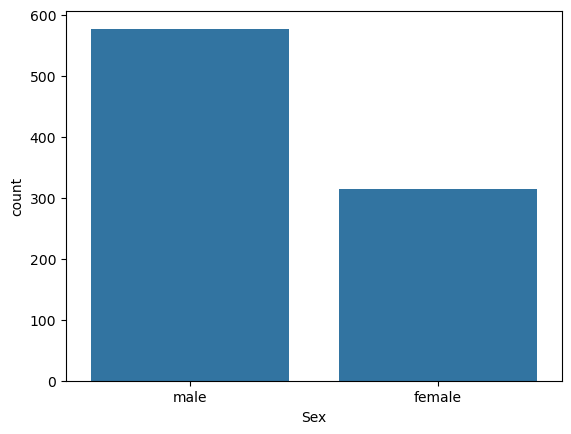

In [148]:
sns.countplot(x=df['Sex'])


<Axes: xlabel='Pclass', ylabel='count'>

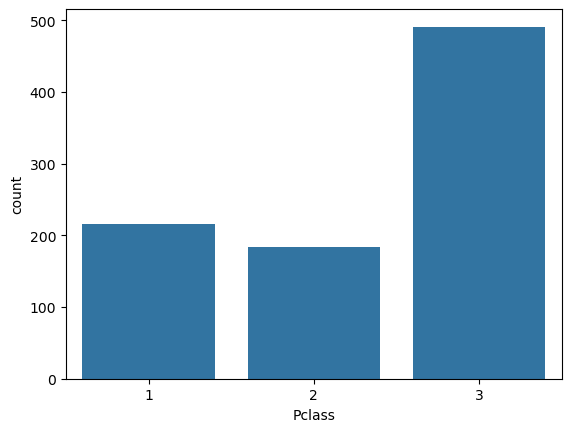

In [149]:
sns.countplot(x=df['Pclass'])


<Axes: xlabel='Survived', ylabel='count'>

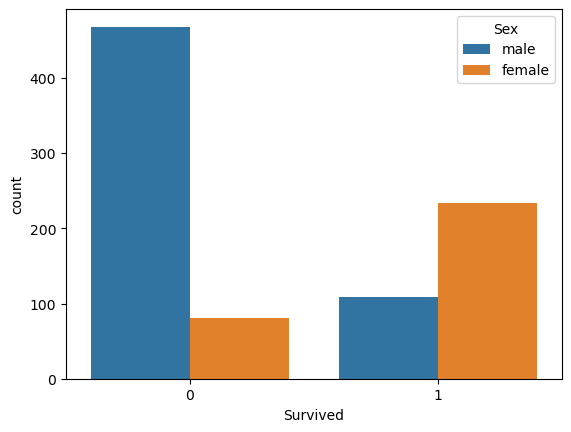

In [150]:
sns.countplot(x=df['Survived'],hue=df['Sex'])


In [151]:
pd.crosstab(df['Survived'], df['Sex'])


Sex,female,male
Survived,,
0,81,468
1,233,109


In [152]:
from sklearn.model_selection import train_test_split
X = df.drop(['Survived'], axis=1)

Y=df['Survived']

In [153]:
X

,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,3,male,22.0,7.2500,S,2
1,1,female,38.0,71.2833,C,2
2,3,female,26.0,7.9250,S,1
3,1,female,35.0,53.1000,S,2
4,3,male,35.0,8.0500,S,1
...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,1
887,1,female,19.0,30.0000,S,1
888,3,female,NaN,23.4500,S,4
889,1,male,26.0,30.0000,C,1


In [154]:
Y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [155]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [156]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

X_train[['Sex']] = encoder.fit_transform(X_train[['Sex']])
X_test[['Sex']] = encoder.transform(X_test[['Sex']])

In [157]:
X_train

,Pclass,Sex,Age,Fare,Embarked,FamilySize
331,1,1.0,45.5,28.5000,S,1
733,2,1.0,23.0,13.0000,S,1
382,3,1.0,32.0,7.9250,S,1
704,3,1.0,26.0,7.8542,S,2
813,3,0.0,6.0,31.2750,S,7
...,...,...,...,...,...,...
106,3,0.0,21.0,7.6500,S,1
270,1,1.0,NaN,31.0000,S,1
860,3,1.0,41.0,14.1083,S,3
435,1,0.0,14.0,120.0000,S,4


In [158]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      712 non-null    int64  
 1   Sex         712 non-null    float64
 2   Age         572 non-null    float64
 3   Fare        712 non-null    float64
 4   Embarked    710 non-null    object 
 5   FamilySize  712 non-null    int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 38.9+ KB


In [159]:
X_test

,Pclass,Sex,Age,Fare,Embarked,FamilySize
709,3,1.0,NaN,15.2458,C,3
439,2,1.0,31.0,10.5000,S,1
840,3,1.0,20.0,7.9250,S,1
720,2,0.0,6.0,33.0000,S,2
39,3,0.0,14.0,11.2417,C,2
...,...,...,...,...,...,...
433,3,1.0,17.0,7.1250,S,1
773,3,1.0,NaN,7.2250,C,1
25,3,0.0,38.0,31.3875,S,7
84,2,0.0,17.0,10.5000,S,1


In [160]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_train['Embarked'] = le.fit_transform(X_train['Embarked'])
X_test['Embarked'] = le.transform(X_test['Embarked'])

In [161]:
X_train



,Pclass,Sex,Age,Fare,Embarked,FamilySize
331,1,1.0,45.5,28.5000,2,1
733,2,1.0,23.0,13.0000,2,1
382,3,1.0,32.0,7.9250,2,1
704,3,1.0,26.0,7.8542,2,2
813,3,0.0,6.0,31.2750,2,7
...,...,...,...,...,...,...
106,3,0.0,21.0,7.6500,2,1
270,1,1.0,NaN,31.0000,2,1
860,3,1.0,41.0,14.1083,2,3
435,1,0.0,14.0,120.0000,2,4


In [162]:
from sklearn.impute import KNNImputer

In [163]:
imputer = KNNImputer(n_neighbors=2)
X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)

In [164]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [165]:
df['Age'].isnull().sum()

np.int64(177)

In [166]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
FamilySize    0
dtype: int64

In [167]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [168]:
X_train.describe()

,Pclass,Sex,Age,Fare,Embarked,FamilySize
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,2.330056,0.655899,29.768341,32.586276,1.567416,1.932584
std,0.824584,0.475408,13.714460,51.969529,0.776559,1.682525
min,1.000000,0.000000,0.420000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,7.925000,1.000000,1.000000
50%,3.000000,1.000000,29.000000,14.454200,2.000000,1.000000
75%,3.000000,1.000000,38.000000,30.500000,2.000000,2.000000
max,3.000000,1.000000,64.812500,512.329200,3.000000,11.000000


In [169]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [170]:

X_test

array([[ 0.81303367,  0.7243102 , -0.38441503, -0.33390078, -2.01983093,
         0.63485883],
       [-0.40055118,  0.7243102 ,  0.08987047, -0.42528387,  0.55744438,
        -0.55466613],
       [ 0.81303367,  0.7243102 , -0.71276652, -0.47486697,  0.55744438,
        -0.55466613],
       ...,
       [ 0.81303367, -1.38062393,  0.60063946, -0.02308312,  0.55744438,
         3.01390875],
       [-0.40055118, -1.38062393, -0.93166752, -0.42528387,  0.55744438,
        -0.55466613],
       [ 0.81303367, -1.38062393, -1.8802385 , -0.30589933,  0.55744438,
         0.63485883]], shape=(179, 6))

In [171]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [172]:
y_pred = model.predict(X_test)

In [173]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [174]:
print(df.isnull().sum())

Survived        0
Pclass          0
Sex             0
Age           177
Fare            0
Embarked        2
FamilySize      0
dtype: int64


In [175]:
X.dtypes

Pclass          int64
Sex            object
Age           float64
Fare          float64
Embarked       object
FamilySize      int64
dtype: object

In [176]:
le = LabelEncoder()

X['Sex'] = le.fit_transform(X['Sex'])
X['Embarked'] = le.fit_transform(X['Embarked'])

In [177]:
X.dtypes

Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked        int64
FamilySize      int64
dtype: object

In [178]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
scores = cross_val_score(dt, X, Y, cv=10)

print(scores.mean())

NameError: name 'cross_val_score' is not defined

In [361]:
import pickle

with open("titanic_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [362]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [363]:
import streamlit
import pandas as pd
import numpy as np
import sklearn

print("Streamlit:", streamlit.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Streamlit: 1.51.0
Pandas: 2.3.3
NumPy: 2.3.5
Scikit-learn: 1.7.2
